In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
df.isnull().sum

<bound method DataFrame.sum of         age    sex    bmi  children  smoker  region  charges
0     False  False  False     False   False   False    False
1     False  False  False     False   False   False    False
2     False  False  False     False   False   False    False
3     False  False  False     False   False   False    False
4     False  False  False     False   False   False    False
...     ...    ...    ...       ...     ...     ...      ...
1333  False  False  False     False   False   False    False
1334  False  False  False     False   False   False    False
1335  False  False  False     False   False   False    False
1336  False  False  False     False   False   False    False
1337  False  False  False     False   False   False    False

[1338 rows x 7 columns]>

In [ ]:
df_ml=pd.get_dummies(df,drop_first=True)
df_ml.head(20)

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
5,31,25.740,0,3756.62160,False,False,False,True,False
6,46,33.440,1,8240.58960,False,False,False,True,False
7,37,27.740,3,7281.50560,False,False,True,False,False
8,37,29.830,2,6406.41070,True,False,False,False,False
9,60,25.840,0,28923.13692,False,False,True,False,False


In [ ]:
df_ml.to_csv('insurance_ml.csv', index=False)

In [ ]:
df_ml

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


In [ ]:
ml_file=pd.read_csv('/content/insurance_ml.csv')
ml_file.head(20)

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
5,31,25.740,0,3756.62160,False,False,False,True,False
6,46,33.440,1,8240.58960,False,False,False,True,False
7,37,27.740,3,7281.50560,False,False,True,False,False
8,37,29.830,2,6406.41070,True,False,False,False,False
9,60,25.840,0,28923.13692,False,False,True,False,False


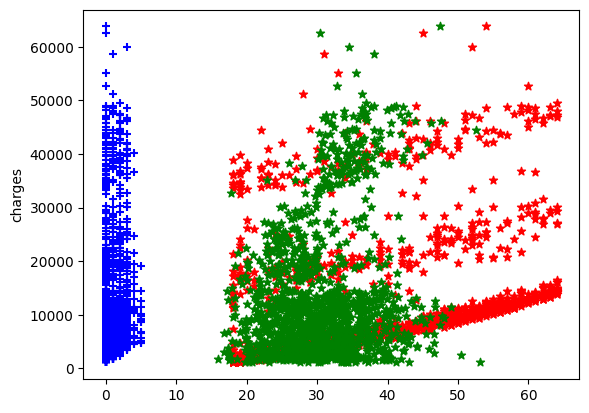

In [64]:
plt.scatter(df_ml.age,df_ml.charges,color='red',marker='*')
plt.scatter(df_ml.bmi,df_ml.charges,color='green',marker='*')
plt.scatter(df_ml.children,df_ml.charges,color='blue',marker='+')
plt.ylabel('charges')
plt.show()




In [71]:
lr=linear_model.LinearRegression()
lr.fit(df_ml[['age','bmi','children','sex_male','smoker_yes','region_northwest','region_southeast',	'region_southwest']],df_ml.charges)

LinearRegression()

In [ ]:
lr.score(df_ml[['age','bmi','children','sex_male','smoker_yes','region_northwest','region_southeast',	'region_southwest']],df_ml.charges)

0.7509130345985207

In [ ]:
#X = ml_file.drop('charges', axis=1)
#y = ml_file['charges']
#best practice

In [ ]:
lr.coef_

array([  256.85635254,   339.19345361,   475.50054515,  -131.3143594 ,
       23848.53454191,  -352.96389942, -1035.02204939,  -960.0509913 ])

In [ ]:
lr.intercept_

np.float64(-11938.538576167146)

In [74]:
lr.predict([[89,34,2,0,1,0,0,1]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([46293.73886334])

In [81]:
lr.predict([[23,27,10,0,1,1,0,0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([31377.95687366])